In [1]:
# Imports, plot settings and random seed
import os
OUTPUT_DIR = './graphiques/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42


In [2]:
# Load data, create target, encode categoricals, standardize features
df = pd.read_csv('INNHotelsGroup.csv')

df['target'] = (df['booking_status'] == 'Canceled').astype(int)

data = df.copy()
data.drop(columns=['Booking_ID', 'booking_status'], inplace=True)

cat_features = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
data_encoded = pd.get_dummies(data, columns=cat_features, drop_first=True, dtype=int)

y = data_encoded['target']
X = data_encoded.drop(columns=['target'])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Dimensions: {X_scaled.shape[0]} rows x {X_scaled.shape[1]} columns")
print("Preprocessing done")


Dimensions: 36275 rows x 27 columns
Preprocessing done


Variance explained by 10 components: 58.67%



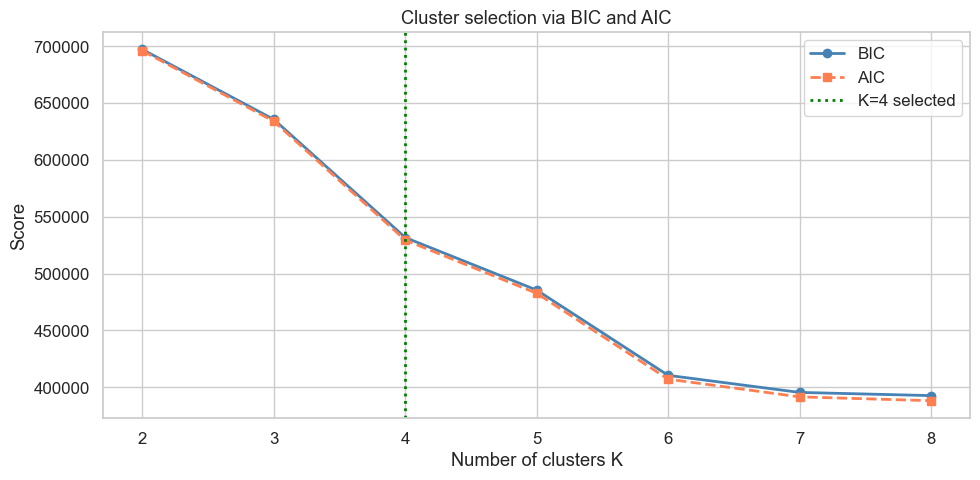

Selected K: 4 (BIC elbow — best fit/complexity tradeoff)

Log-likelihood: -7.29
EM iterations: 24

Cluster distribution:
  Cluster 0: 11415 bookings (31.5%)
  Cluster 1: 12593 bookings (34.7%)
  Cluster 2: 9309 bookings (25.7%)
  Cluster 3: 2958 bookings (8.2%)


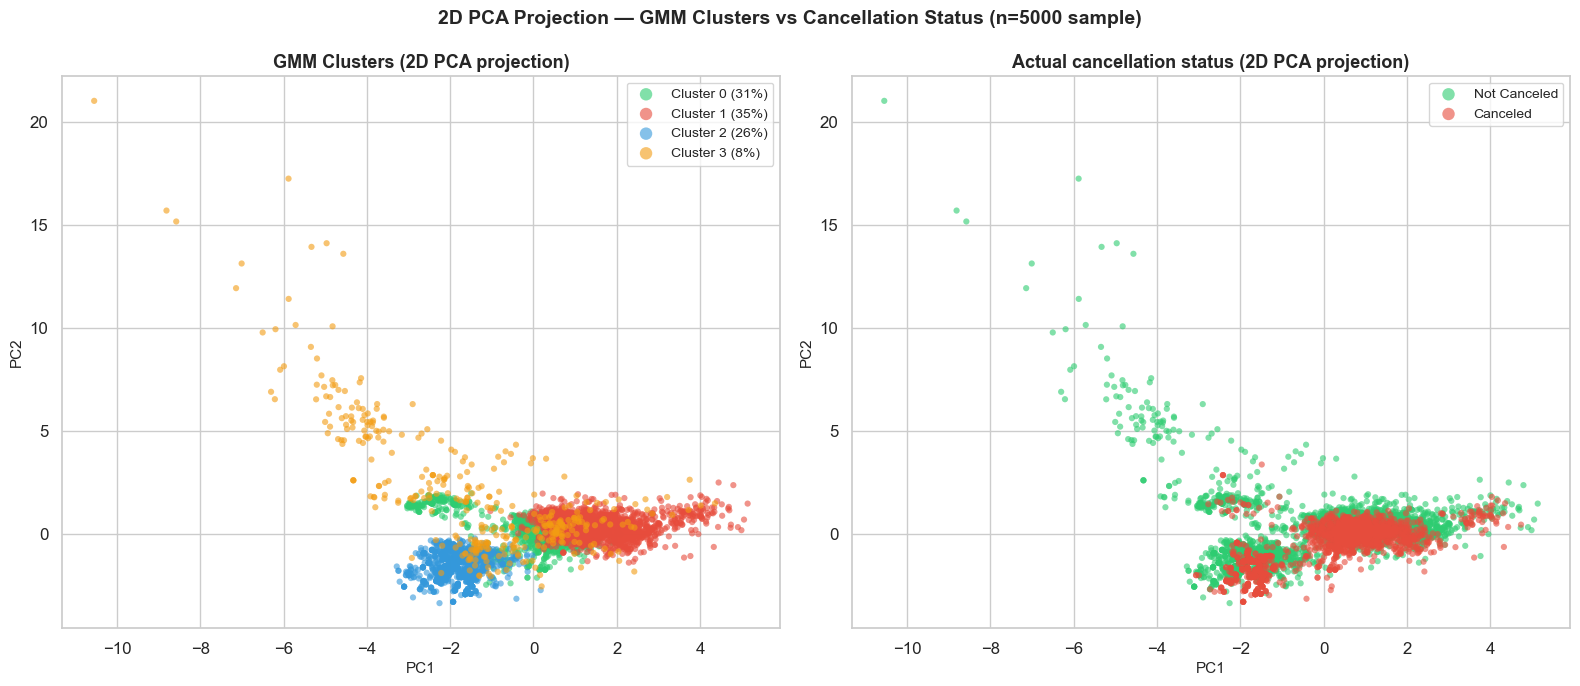

In [3]:
# PCA reduction, BIC/AIC cluster selection, GMM fitting, 2D PCA visualization
pca_pre = PCA(n_components=10, random_state=RANDOM_STATE)
X_pca = pca_pre.fit_transform(X_scaled)
print(f"Variance explained by 10 components: {pca_pre.explained_variance_ratio_.sum():.2%}\n")

n_components_range = range(2, 9)
bic_scores = []
aic_scores = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full',
                          random_state=RANDOM_STATE, max_iter=200)
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))
    aic_scores.append(gmm.aic(X_pca))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_components_range, bic_scores, 'o-', label='BIC', linewidth=2, color='steelblue')
ax.plot(n_components_range, aic_scores, 's--', label='AIC', linewidth=2, color='coral')
ax.axvline(x=4, color='green', linestyle=':', linewidth=2, label='K=4 selected')
ax.set_xlabel("Number of clusters K")
ax.set_ylabel("Score")
ax.set_title("Cluster selection via BIC and AIC")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'bic_aic.png', dpi=100, bbox_inches='tight')
plt.show()

K_optimal = 4
print(f"Selected K: {K_optimal} (BIC elbow — best fit/complexity tradeoff)\n")

gmm_final = GaussianMixture(n_components=K_optimal, covariance_type='full',
                             random_state=RANDOM_STATE, max_iter=200)
gmm_final.fit(X_pca)
labels = gmm_final.predict(X_pca)
proba = gmm_final.predict_proba(X_pca)

print(f"Log-likelihood: {gmm_final.lower_bound_:.2f}")
print(f"EM iterations: {gmm_final.n_iter_}")
print(f"\nCluster distribution:")
unique, counts = np.unique(labels, return_counts=True)
for k, c in zip(unique, counts):
    print(f"  Cluster {k}: {c} bookings ({c/len(labels)*100:.1f}%)")

pca_visu = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_visu.fit_transform(X_scaled)

np.random.seed(RANDOM_STATE)
idx_sample = np.random.choice(len(X_2d), size=5000, replace=False)

colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for k in range(K_optimal):
    mask = labels[idx_sample] == k
    axes[0].scatter(X_2d[idx_sample][mask, 0], X_2d[idx_sample][mask, 1],
                    c=colors[k], label=f'Cluster {k} ({counts[k]/len(labels)*100:.0f}%)',
                    alpha=0.6, s=20, edgecolors='none')
axes[0].set_title("GMM Clusters (2D PCA projection)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("PC1", fontsize=11)
axes[0].set_ylabel("PC2", fontsize=11)
axes[0].legend(fontsize=10, markerscale=2)

for val, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Not Canceled', 'Canceled']):
    mask = y.values[idx_sample] == val
    axes[1].scatter(X_2d[idx_sample][mask, 0], X_2d[idx_sample][mask, 1],
                    c=color, label=name, alpha=0.6, s=20, edgecolors='none')
axes[1].set_title("Actual cancellation status (2D PCA projection)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("PC1", fontsize=11)
axes[1].set_ylabel("PC2", fontsize=11)
axes[1].legend(fontsize=10, markerscale=2)

plt.suptitle("2D PCA Projection — GMM Clusters vs Cancellation Status (n=5000 sample)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'clusters_pca.png', dpi=100, bbox_inches='tight')
plt.show()


=== AVERAGE PROFILE PER CLUSTER ===
         lead_time  avg_price_per_room  no_of_special_requests  no_of_weekend_nights  no_of_week_nights  repeated_guest  no_of_previous_cancellations  cancellation_rate_%
cluster                                                                                                                                                                   
0            78.67               98.27                    0.70                  0.84               2.22            0.00                          0.00                 33.0
1            66.42              121.54                    0.89                  0.87               2.26            0.00                          0.00                 36.0
2           130.70               91.65                    0.18                  0.70               2.15            0.00                          0.00                 33.0
3            47.58               83.23                    0.59                  0.79               2.10      

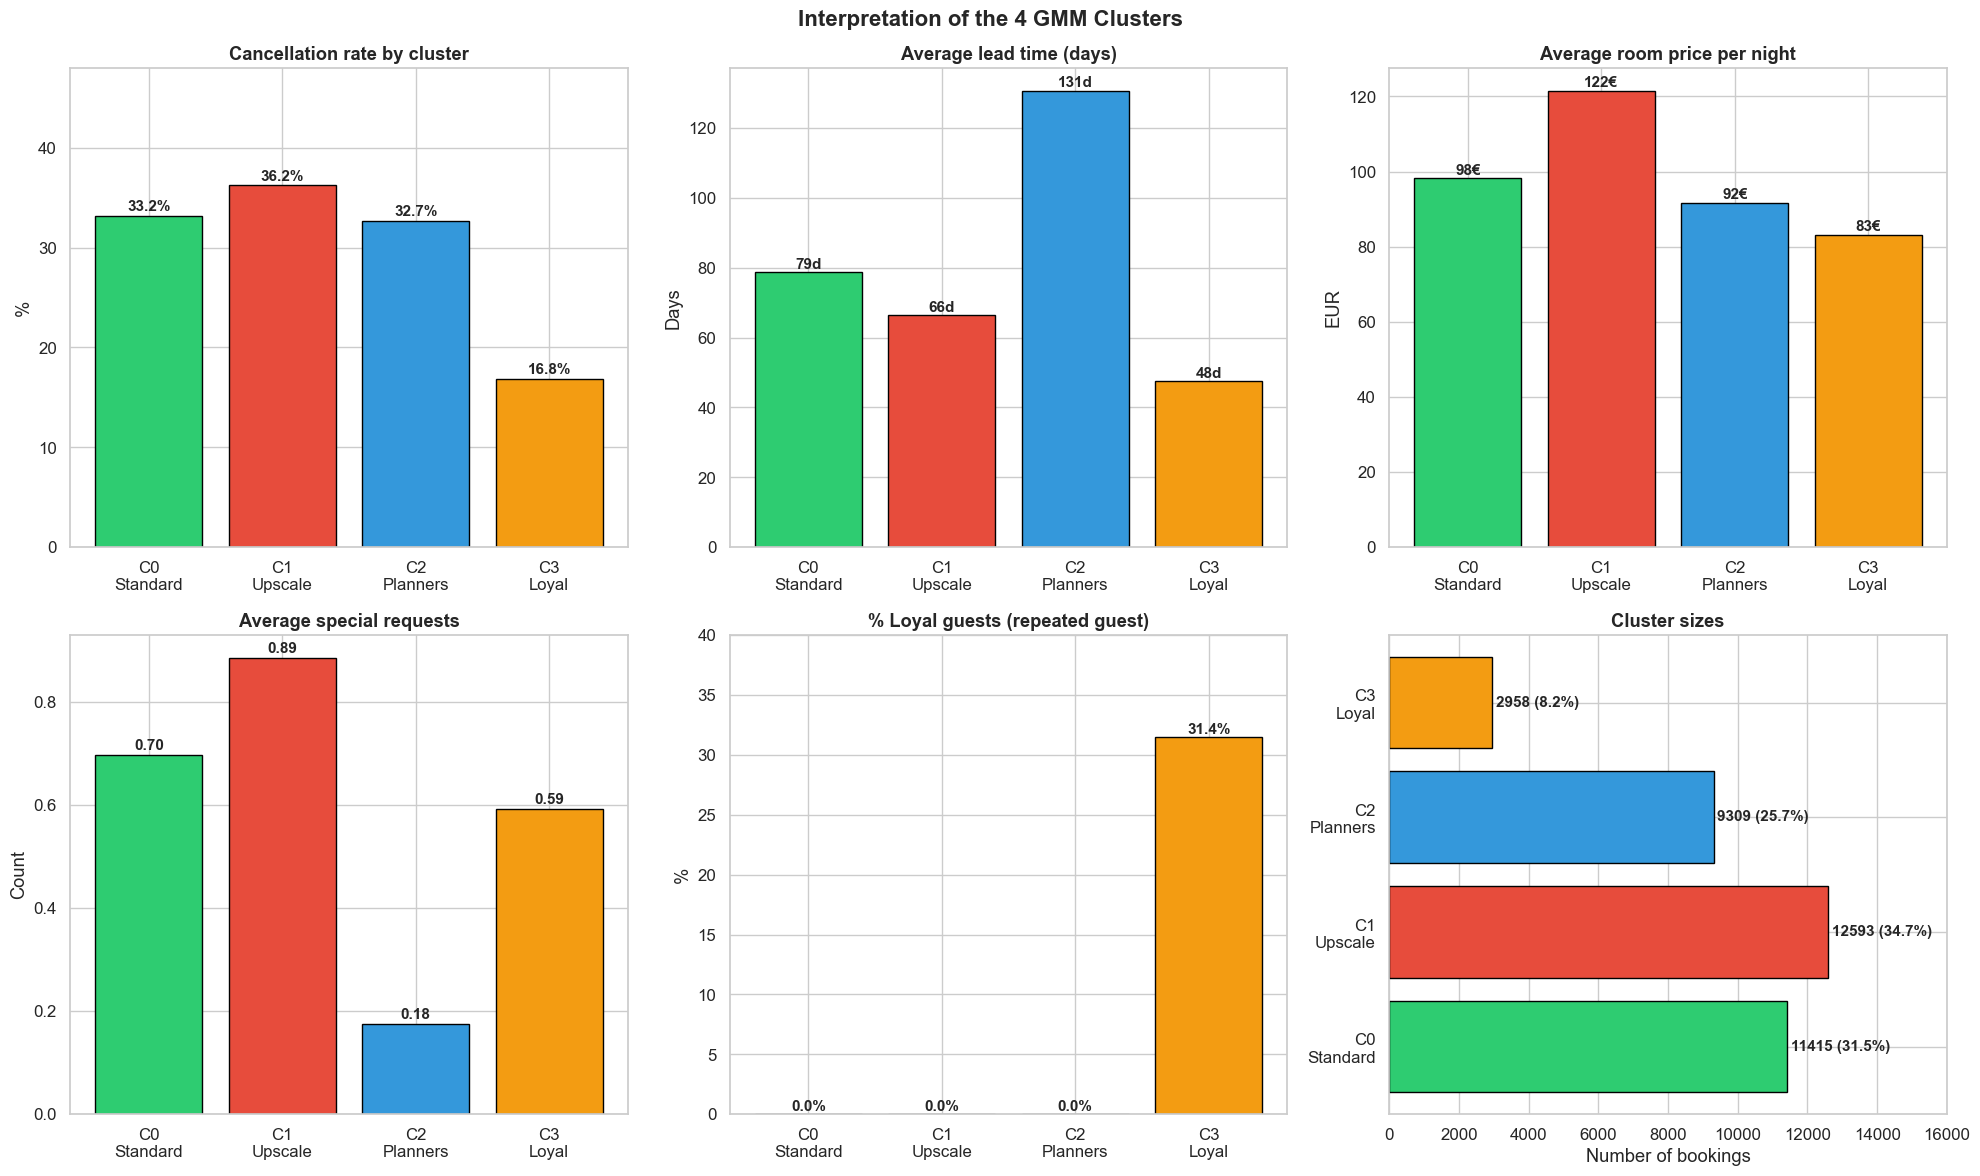

In [4]:
# Cluster profiling and interpretation plots
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
cluster_names = ['C0\nStandard', 'C1\nUpscale', 'C2\nPlanners', 'C3\nLoyal']

df_profile = df.copy()
df_profile['cluster'] = labels

key_vars = ['lead_time', 'avg_price_per_room', 'no_of_special_requests',
            'no_of_weekend_nights', 'no_of_week_nights',
            'repeated_guest', 'no_of_previous_cancellations']
profile = df_profile.groupby('cluster')[key_vars + ['target']].mean().round(2)
profile['cancellation_rate_%'] = (profile['target'] * 100).round(1)
profile = profile.drop(columns='target')
print("=== AVERAGE PROFILE PER CLUSTER ===")
print(profile.to_string())

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

cancel_rate = df_profile.groupby('cluster')['target'].mean() * 100
axes[0].bar(cluster_names, cancel_rate.values, color=colors, edgecolor='black')
for i, v in enumerate(cancel_rate.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title("Cancellation rate by cluster", fontweight='bold')
axes[0].set_ylabel('%')
axes[0].set_ylim(0, 48)

lt = df_profile.groupby('cluster')['lead_time'].mean()
axes[1].bar(cluster_names, lt.values, color=colors, edgecolor='black')
for i, v in enumerate(lt.values):
    axes[1].text(i, v + 1, f'{v:.0f}d', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title("Average lead time (days)", fontweight='bold')
axes[1].set_ylabel('Days')

price = df_profile.groupby('cluster')['avg_price_per_room'].mean()
axes[2].bar(cluster_names, price.values, color=colors, edgecolor='black')
for i, v in enumerate(price.values):
    axes[2].text(i, v + 1, f'{v:.0f}€', ha='center', fontweight='bold', fontsize=11)
axes[2].set_title("Average room price per night", fontweight='bold')
axes[2].set_ylabel('EUR')

sr = df_profile.groupby('cluster')['no_of_special_requests'].mean()
axes[3].bar(cluster_names, sr.values, color=colors, edgecolor='black')
for i, v in enumerate(sr.values):
    axes[3].text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)
axes[3].set_title("Average special requests", fontweight='bold')
axes[3].set_ylabel('Count')

rg = df_profile.groupby('cluster')['repeated_guest'].mean() * 100
axes[4].bar(cluster_names, rg.values, color=colors, edgecolor='black')
for i, v in enumerate(rg.values):
    axes[4].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[4].set_title("% Loyal guests (repeated guest)", fontweight='bold')
axes[4].set_ylabel('%')
axes[4].set_ylim(0, 40)

sizes = [df_profile[df_profile['cluster'] == k].shape[0] for k in range(4)]
axes[5].barh(cluster_names, sizes, color=colors, edgecolor='black')
for i, v in enumerate(sizes):
    axes[5].text(v + 100, i, f'{v} ({v/len(df_profile)*100:.1f}%)',
                 va='center', fontweight='bold', fontsize=11)
axes[5].set_title("Cluster sizes", fontweight='bold')
axes[5].set_xlabel('Number of bookings')
axes[5].set_xlim(0, 16000)

plt.suptitle("Interpretation of the 4 GMM Clusters", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'profil_clusters.png', dpi=100, bbox_inches='tight')
plt.show()


Average membership probability: 0.989
% observations with proba > 0.9: 96.9%
% observations with proba < 0.6: 0.4%


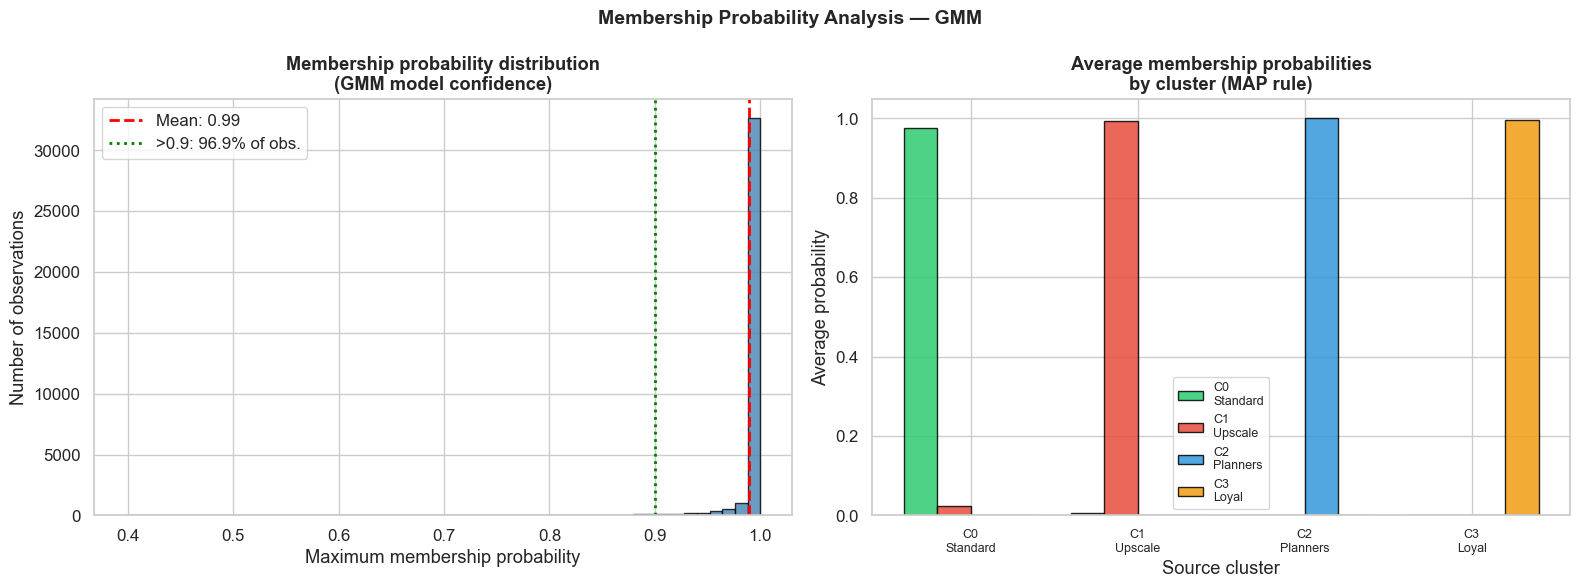

In [5]:
# Membership probability analysis (MAP rule)
max_proba = proba.max(axis=1)
print(f"Average membership probability: {max_proba.mean():.3f}")
print(f"% observations with proba > 0.9: {(max_proba > 0.9).mean()*100:.1f}%")
print(f"% observations with proba < 0.6: {(max_proba < 0.6).mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(max_proba, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(x=max_proba.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {max_proba.mean():.2f}')
axes[0].axvline(x=0.9, color='green', linestyle=':', linewidth=2,
                label=f'>0.9: {(max_proba>0.9).mean()*100:.1f}% of obs.')
axes[0].set_title("Membership probability distribution\n(GMM model confidence)", fontweight='bold')
axes[0].set_xlabel("Maximum membership probability")
axes[0].set_ylabel("Number of observations")
axes[0].legend()

proba_df = pd.DataFrame(proba, columns=[f'P(C{k})' for k in range(K_optimal)])
proba_df['cluster'] = labels
mean_proba_by_cluster = proba_df.groupby('cluster').mean()

x = np.arange(K_optimal)
width = 0.2
for k in range(K_optimal):
    axes[1].bar(x + k*width, mean_proba_by_cluster[f'P(C{k})'].values,
                width, label=cluster_names[k], color=colors[k], edgecolor='black', alpha=0.85)

axes[1].set_title("Average membership probabilities\nby cluster (MAP rule)", fontweight='bold')
axes[1].set_xlabel("Source cluster")
axes[1].set_ylabel("Average probability")
axes[1].set_xticks(x + width*1.5)
axes[1].set_xticklabels(cluster_names, fontsize=9)
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.05)

plt.suptitle("Membership Probability Analysis — GMM", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'probas_appartenance.png', dpi=100, bbox_inches='tight')
plt.show()
